In [53]:
# import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
study_data = pd.read_csv('Study_Data.csv')
study_data

,HoursStudied,PracticeTests,Passed
0,0.7,5,0
1,0.9,8,0
2,1.1,6,0
3,1.1,7,0
4,1.4,7,1
5,1.8,8,1
6,2.0,3,0
7,2.0,1,0
8,2.1,8,0
9,2.2,1,0


In [55]:
# 2 input (HoursStudied, PracticeTests) dan 1 output (Passed)
X = study_data.iloc[:, :2].values
y = study_data.iloc[:, 2].values

In [56]:
X.shape

(40, 2)

In [57]:
y

array([0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1])

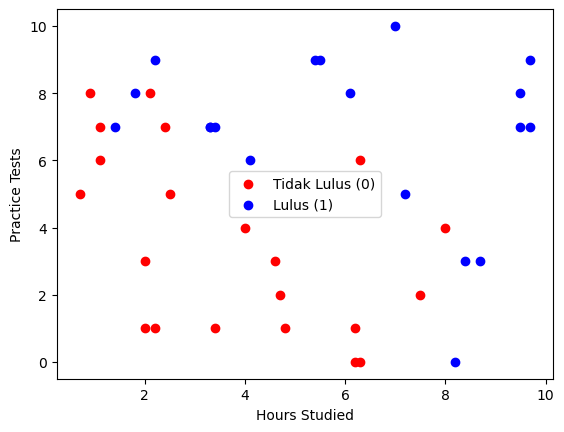

In [58]:
# Visualization

plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Tidak Lulus (0)')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Lulus (1)')
plt.xlabel('Hours Studied')
plt.ylabel('Practice Tests')
plt.legend()
plt.show()

In [59]:
# train_test_split:
# this function splits the dataset into training and testing sets based on the specified test size and random state.
# the method takes in the features (X), target variable (y), test size, and random state as inputs and returns the training and testing sets for both features and target variable.
# example usage:
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

def train_test_split(X, y, test_size=0.25, random_state=None):
    X = np.asarray(X)
    y = np.asarray(y)

    if not 0 < test_size < 1:
        raise ValueError("test_size must be between 0 and 1")

    n_total = len(X)
    n_test = int(round(n_total * test_size))

    if random_state is not None:
        rng = np.random.RandomState(random_state)
        indices = rng.permutation(n_total)
    else:
        indices = np.random.permutation(n_total)

    test_idx = indices[:n_test]
    train_idx = indices[n_test:]

    X_train = X[train_idx]
    X_test = X[test_idx]
    y_train = y[train_idx]
    y_test = y[test_idx]

    return X_train, X_test, y_train, y_test

In [60]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=7)

In [61]:
print('X_train: ', X_train.shape)
print('y_train: ', y_train.shape)
print('X_test: ', X_test.shape)
print('y_test: ', y_test.shape)

X_train:  (30, 2)
y_train:  (30,)
X_test:  (10, 2)
y_test:  (10,)


In [62]:
# Logistic Regression Implementation
# the LogisticRegression class implements a simple binary classification model. It learns the weights with gradient descent,
# predict_proba returns the probability of class 1, and predict turns that probability into class 0 or 1 using a threshold.
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=10000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.intercept_ = 0.0
        self.coefficients_ = None
        self.loss_history_ = []
        self.beta_history_ = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        X_b = np.c_[np.ones(len(X)), X]
        beta = np.zeros(X_b.shape[1])

        for _ in range(self.n_iterations):
            p = self._sigmoid(X_b @ beta)
            gradient = X_b.T @ (p - y) / len(y)
            beta = beta - self.learning_rate * gradient

            p = np.clip(p, 1e-15, 1 - 1e-15)
            loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
            self.loss_history_.append(loss)
            self.beta_history_.append(beta.copy())

        self.intercept_ = beta[0]
        self.coefficients_ = beta[1:]
        return self

    def predict_proba(self, X):
        X = np.array(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return self._sigmoid(self.intercept_ + X @ self.coefficients_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [63]:
#Fitting Model
classifier = LogisticRegression(learning_rate=0.1, n_iterations=10000)
classifier.fit(X_train, y_train)

In [64]:
print('intercept: ', classifier.intercept_)
print('coefficient: ', classifier.coefficients_)

intercept:  -7.6280305838678855
coefficient:  [0.7610881  0.82369597]


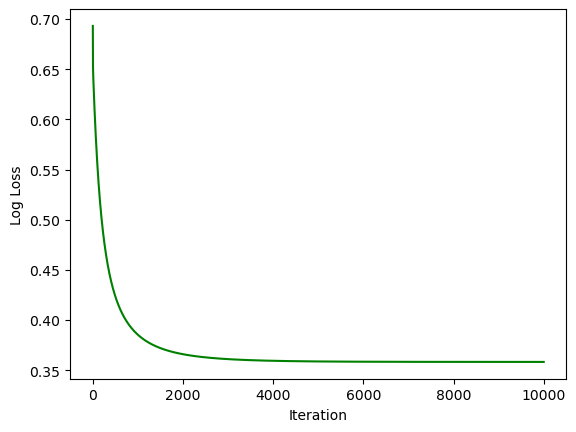

In [65]:
# Loss during training (should go down)

plt.plot(classifier.loss_history_, c='g')
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.show()

In [78]:
# # Animation: how the decision boundary moves during training
# # beta_history_ stores [b, m1, m2] for every iteration, so we can replay the training step by step.
# # the line moves a lot in the first iterations and only a little at the end,
# # so the frames are taken on a log scale (many frames at the start, few at the end).
# from matplotlib.animation import FuncAnimation, PillowWriter
# from IPython.display import HTML

# beta_history = np.array(classifier.beta_history_)
# loss_history = np.array(classifier.loss_history_)
# iterations = np.arange(1, len(loss_history) + 1)
# frames = np.unique(np.geomspace(1, len(beta_history), 80).astype(int)) - 1

# x1, x2 = np.meshgrid(np.linspace(0, 10.5, 150), np.linspace(-0.5, 10.5, 150))
# grid = np.c_[x1.ravel(), x2.ravel()]
# x1_line = np.linspace(0, 10.5, 100)

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5), dpi=80)

# # left: training data + probability background + decision boundary
# background = ax1.imshow(np.zeros(x1.shape), extent=(0, 10.5, -0.5, 10.5), origin='lower',
#                         cmap='RdBu', vmin=0, vmax=1, alpha=0.4, aspect='auto')
# ax1.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='red', edgecolors='k', label='Tidak Lulus (0)')
# ax1.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='blue', edgecolors='k', label='Lulus (1)')
# boundary, = ax1.plot([], [], c='g', lw=2, label='Decision boundary')
# ax1.set_xlim(0, 10.5)
# ax1.set_ylim(-0.5, 10.5)
# ax1.set_xlabel('Hours Studied')
# ax1.set_ylabel('Practice Tests')
# ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.13), ncol=3)
# title = ax1.set_title('')

# # right: loss curve with a dot showing the current iteration
# ax2.plot(iterations, loss_history, c='lightgray')
# loss_line, = ax2.plot([], [], c='g')
# loss_point, = ax2.plot([], [], 'o', c='r')
# ax2.set_xscale('log')
# ax2.set_xlabel('Iteration (log scale)')
# ax2.set_ylabel('Log Loss')
# ax2.set_title('Loss')
# fig.tight_layout()

# def update(i):
#     b, m1, m2 = beta_history[i]

#     proba = classifier._sigmoid(b + grid @ np.array([m1, m2])).reshape(x1.shape)
#     background.set_data(proba)
#     boundary.set_data(x1_line, -(b + m1 * x1_line) / m2)

#     loss_line.set_data(iterations[:i + 1], loss_history[:i + 1])
#     loss_point.set_data([iterations[i]], [loss_history[i]])

#     train_pred = (classifier._sigmoid(b + X_train @ np.array([m1, m2])) >= 0.5).astype(int)
#     train_acc = np.mean(train_pred == y_train)
#     title.set_text(f'Iteration {i + 1}  |  loss = {loss_history[i]:.3f}  |  train accuracy = {train_acc:.2f}')
#     return background, boundary, loss_line, loss_point, title

# anim = FuncAnimation(fig, update, frames=frames, interval=100)
# plt.close(fig)

# plt.rcParams['animation.frame_format'] = 'jpeg'  # smaller notebook file than png frames
# HTML(anim.to_jshtml())

In [77]:
# Save the animation as a GIF (for slides / sharing)
# anim.save('training_animation.gif', writer=PillowWriter(fps=10))

In [68]:
y_test

array([0, 1, 1, 1, 0, 0, 1, 0, 0, 1])

In [69]:
y_pred = classifier.predict(X_test)
y_pred

array([0, 1, 1, 1, 1, 0, 1, 0, 0, 1])

In [70]:
y_proba = classifier.predict_proba(X_test)
y_proba.round(3)

array([0.216, 0.995, 0.775, 0.607, 0.853, 0.413, 0.98 , 0.136, 0.006,
       0.998])

In [71]:
# Evaluation
# accuracy: fraction of predictions that match the real label
# confusion_matrix: [[TN, FP],
#                    [FN, TP]]

def accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)

def confusion_matrix(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))

    return np.array([[tn, fp],
                     [fn, tp]])

In [72]:
print('Accuracy: ', accuracy_score(y_test, y_pred))
print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.9
Confusion Matrix:
[[4 1]
 [0 5]]


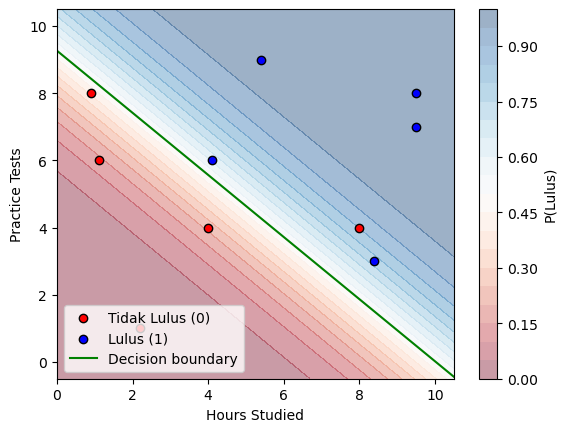

In [73]:
# Visualization
# background color = probability of passing, green line = decision boundary (probability = 0.5)

x1, x2 = np.meshgrid(np.linspace(0, 10.5, 200), np.linspace(-0.5, 10.5, 200))
grid = np.c_[x1.ravel(), x2.ravel()]
proba = classifier.predict_proba(grid).reshape(x1.shape)

b = classifier.intercept_
m1, m2 = classifier.coefficients_
x1_line = np.linspace(0, 10.5, 100)
x2_line = -(b + m1 * x1_line) / m2

plt.contourf(x1, x2, proba, levels=20, cmap='RdBu', alpha=0.4)
plt.colorbar(label='P(Lulus)')
plt.scatter(X_test[y_test == 0, 0], X_test[y_test == 0, 1], c='red', edgecolors='k', label='Tidak Lulus (0)')
plt.scatter(X_test[y_test == 1, 0], X_test[y_test == 1, 1], c='blue', edgecolors='k', label='Lulus (1)')
plt.plot(x1_line, x2_line, c='g', label='Decision boundary')
plt.xlim(0, 10.5)
plt.ylim(-0.5, 10.5)
plt.xlabel('Hours Studied')
plt.ylabel('Practice Tests')
plt.legend(loc='lower left')
plt.show()

In [74]:
# [HoursStudied, PracticeTests]
prediksi = classifier.predict([[2.0, 3],[7.0, 8]])
prediksi

array([0, 1])

In [75]:
prediksi_proba = classifier.predict_proba([[2.0, 3],[7.0, 8]])
prediksi_proba

array([0.02571157, 0.98646907])

# Algoritma Logistic Regression

Logistic Regression adalah algoritma **klasifikasi** yang digunakan untuk memprediksi kelas dari data, misalnya:
- Lulus (1) atau Tidak Lulus (0)
- Spam (1) atau Bukan Spam (0)

Walaupun namanya "regression", algoritma ini dipakai untuk **klasifikasi**. Bedanya dengan Linear Regression:

| | Linear Regression | Logistic Regression |
|---|---|---|
| Output | angka kontinu (misal gaji) | probabilitas 0 – 1, lalu kelas 0 / 1 |
| Fungsi | garis lurus $y = b + mX$ | kurva sigmoid $\sigma(b + m_1X_1 + m_2X_2)$ |
| Cara belajar | normal equation | gradient descent |
| Evaluasi | error (MSE, R²) | accuracy, confusion matrix |

## Fungsi Sigmoid

Pertama, kita hitung nilai linear seperti pada Linear Regression:

$$
z = b + m_1 X_1 + m_2 X_2
$$

Lalu nilai $z$ dimasukkan ke fungsi **sigmoid** agar hasilnya berada di antara 0 dan 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Keterangan:
- $\sigma(z)$ = probabilitas data termasuk kelas 1 (Lulus)
- $X_1$ = input pertama (jam belajar / `HoursStudied`)
- $X_2$ = input kedua (jumlah latihan soal / `PracticeTests`)
- $b$ = intercept
- $m_1, m_2$ = koefisien untuk masing-masing input

Sifat sigmoid:
- $z$ sangat besar → $\sigma(z) \approx 1$
- $z = 0$ → $\sigma(z) = 0.5$
- $z$ sangat kecil → $\sigma(z) \approx 0$

## Tujuan algoritma

Tujuan dari Logistic Regression adalah mencari nilai $b$, $m_1$, dan $m_2$ agar probabilitas yang diprediksi:
- mendekati 1 untuk data yang benar-benar Lulus
- mendekati 0 untuk data yang benar-benar Tidak Lulus

## Rumus utama

### Loss function (Log Loss / Binary Cross-Entropy)

Untuk mengukur seberapa salah model, kita gunakan log loss:

$$
L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]
$$

Dimana:
- $y_i$ = label sebenarnya (0 atau 1)
- $\hat{p}_i$ = probabilitas prediksi
- $n$ = jumlah data

Semakin kecil loss, semakin baik model.

### Gradient Descent

Berbeda dengan Linear Regression, Logistic Regression **tidak punya rumus langsung** (normal equation). Jadi kita mencari $\beta$ secara bertahap dengan gradient descent:

$$
\nabla = \frac{1}{n} X^T (\hat{p} - y)
$$

$$
\beta = \beta - \alpha \cdot \nabla
$$

Dimana:
- $\nabla$ = gradient (arah kenaikan loss)
- $\alpha$ = learning rate (besar langkah)
- $\beta$ = koefisien model $[b, m_1, m_2]$

Langkah ini diulang sebanyak `n_iterations` kali.

## Langkah-langkah algoritma

### 1. Ubah data menjadi array
Kode pertama-tama mengubah data menjadi format NumPy:

```python
X = np.array(X, dtype=float)
y = np.array(y, dtype=float)
```

### 2. Jika data 1 dimensi, ubah ke 2 dimensi
Data kita sudah 2 dimensi (40 baris × 2 kolom), jadi langkah ini hanya pengaman jika model dipakai dengan 1 input saja.

```python
if X.ndim == 1:
    X = X.reshape(-1, 1)
```

### 3. Tambahkan kolom bias
Sama seperti Linear Regression, kita menambahkan kolom 1 agar model juga menghitung intercept:

```python
X_b = np.c_[np.ones(len(X)), X]
```

Contoh:

```python
X = [[2.0, 3],
     [7.0, 8]]
```

menjadi:

```python
X_b = [[1, 2.0, 3],
       [1, 7.0, 8]]
```

### 4. Inisialisasi koefisien
Semua koefisien dimulai dari 0. Karena ada 2 input + 1 intercept, `beta` berisi 3 angka:

```python
beta = np.zeros(X_b.shape[1])
```

### 5. Ulangi gradient descent
Di setiap iterasi:

```python
p = self._sigmoid(X_b @ beta)              # hitung probabilitas
gradient = X_b.T @ (p - y) / len(y)        # hitung gradient
beta = beta - self.learning_rate * gradient  # update koefisien
```

Loss juga disimpan di `loss_history_` supaya kita bisa melihat apakah model benar-benar belajar (loss harus turun).

Nilai `beta` di setiap iterasi juga disimpan di `beta_history_`. Data ini dipakai untuk membuat **animasi** pergerakan decision boundary selama training.

### 6. Simpan hasil model

```python
self.intercept_ = beta[0]
self.coefficients_ = beta[1:]
```

### 7. Prediksi probabilitas

```python
return self._sigmoid(self.intercept_ + X @ self.coefficients_)
```

Ini sama dengan:

$$
\hat{p} = \sigma(b + m_1 X_1 + m_2 X_2)
$$

### 8. Prediksi kelas
Probabilitas diubah menjadi kelas menggunakan **threshold** (default 0.5):

```python
return (self.predict_proba(X) >= threshold).astype(int)
```

- $\hat{p} \geq 0.5$ → kelas 1 (Lulus)
- $\hat{p} < 0.5$ → kelas 0 (Tidak Lulus)

## Decision Boundary

Decision boundary adalah batas di mana probabilitas tepat 0.5, yaitu ketika $z = 0$:

$$
b + m_1 X_1 + m_2 X_2 = 0 \quad \Rightarrow \quad X_2 = -\frac{b + m_1 X_1}{m_2}
$$

Karena ada 2 input, decision boundary berbentuk **garis lurus** pada grafik $X_1$ (jam belajar) vs $X_2$ (latihan soal):
- data di atas/kanan garis → diprediksi **Lulus**
- data di bawah/kiri garis → diprediksi **Tidak Lulus**

## Evaluasi Model

### Accuracy

$$
\text{Accuracy} = \frac{\text{jumlah prediksi benar}}{\text{jumlah data}}
$$

### Confusion Matrix

| | Prediksi 0 | Prediksi 1 |
|---|---|---|
| **Aktual 0** | TN (True Negative) | FP (False Positive) |
| **Aktual 1** | FN (False Negative) | TP (True Positive) |

- **TN** = Tidak Lulus, diprediksi Tidak Lulus (benar)
- **FP** = Tidak Lulus, diprediksi Lulus (salah)
- **FN** = Lulus, diprediksi Tidak Lulus (salah)
- **TP** = Lulus, diprediksi Lulus (benar)

## Penjelasan kode lengkap

```python
class LogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=10000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.intercept_ = 0.0
        self.coefficients_ = None
        self.loss_history_ = []
        self.beta_history_ = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.array(X, dtype=float)
        y = np.array(y, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        X_b = np.c_[np.ones(len(X)), X]
        beta = np.zeros(X_b.shape[1])

        for _ in range(self.n_iterations):
            p = self._sigmoid(X_b @ beta)
            gradient = X_b.T @ (p - y) / len(y)
            beta = beta - self.learning_rate * gradient

            p = np.clip(p, 1e-15, 1 - 1e-15)
            loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
            self.loss_history_.append(loss)
            self.beta_history_.append(beta.copy())

        self.intercept_ = beta[0]
        self.coefficients_ = beta[1:]
        return self

    def predict_proba(self, X):
        X = np.array(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return self._sigmoid(self.intercept_ + X @ self.coefficients_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)
```

## Intuisi sederhana

Bayangkan Anda punya data jam belajar, jumlah latihan soal, dan hasil ujian seperti ini:

- 1 jam, 2 latihan → Tidak Lulus
- 2 jam, 1 latihan → Tidak Lulus
- 5 jam, 6 latihan → Lulus
- 8 jam, 9 latihan → Lulus

Model menggabungkan kedua input menjadi satu skor $z$, lalu sigmoid mengubahnya menjadi probabilitas:
- jam belajar dan latihan sedikit → probabilitas lulus mendekati 0
- jam belajar dan latihan banyak → probabilitas lulus mendekati 1
- jam belajar sedikit bisa "ditutupi" dengan latihan yang banyak, dan sebaliknya
- koefisien $m_1$ dan $m_2$ menunjukkan seberapa besar pengaruh masing-masing input

## Kesimpulan

Algoritma Logistic Regression bekerja dengan cara:

1. Menyiapkan 2 data input dan 1 target (0/1)
2. Menambahkan kolom bias
3. Menghitung probabilitas dengan fungsi sigmoid
4. Memperbaiki koefisien sedikit demi sedikit dengan gradient descent
5. Menyimpan intercept dan koefisien
6. Mengubah probabilitas menjadi kelas dengan threshold 0.5
7. Mengevaluasi model dengan accuracy dan confusion matrix

Itulah dasar dari model Logistic Regression untuk klasifikasi.